In [1]:
import os
import sys
import psutil
import pyarrow as pa
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "..")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() - 1 or 1
_TOTAL_MEMORY = psutil.virtual_memory().total
_AVAILABLE_MEMORY = psutil.virtual_memory().available
_MEMORY_PER_WORKER = max(100 * 1024**2, _AVAILABLE_MEMORY // (_NCPU + 1))
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | {_TOTAL_MEMORY / 1024**3:.1f}GB total RAM ({_AVAILABLE_MEMORY / 1024**3:.1f}GB available) | pyarrow {pa.__version__}", flush=True)


Running with 47 CPU cores | 92.3GB total RAM (88.2GB available) | pyarrow 24.0.0


Variables

In [2]:
%run 0_variables.ipynb

Correlation matrix

In [3]:
import time as _time
_stem = Path(os.environ['FEATURE_DATASET']).stem
_fd_path = resolve(f"3_Features_select/Selected_features/{os.environ['TARGET']}_feature_data_{_stem}.parquet")
print(f"Loading feature data parquet: {_fd_path}", flush=True)
_t = _time.perf_counter()
feature_data = pd.read_parquet(_fd_path)
print(f"  loaded feature_data: shape={feature_data.shape} in {_time.perf_counter() - _t:.1f}s", flush=True)

OUTPUT_RESOLUTION = int(os.environ["OUTPUT_RESOLUTION"])
horizon_cols = [c for c in feature_data.columns if c.startswith("h") and c[1:].isdigit()]
horizon_cols = sorted(horizon_cols, key=lambda c: int(c[1:]))
mi_df = feature_data.set_index("feature")[horizon_cols]
print(f"  MI matrix: {mi_df.shape[0]} features × {len(horizon_cols)} horizons ({OUTPUT_RESOLUTION}-min each)", flush=True)


Loading feature data parquet: /home/ec2-user/Forecasting/3_Features_select/../3_Features_select/Selected_features/NSW_feature_data_1_dispatch_price.parquet
  loaded feature_data: shape=(634, 101) in 0.0s
  MI matrix: 634 features × 96 horizons (30-min each)


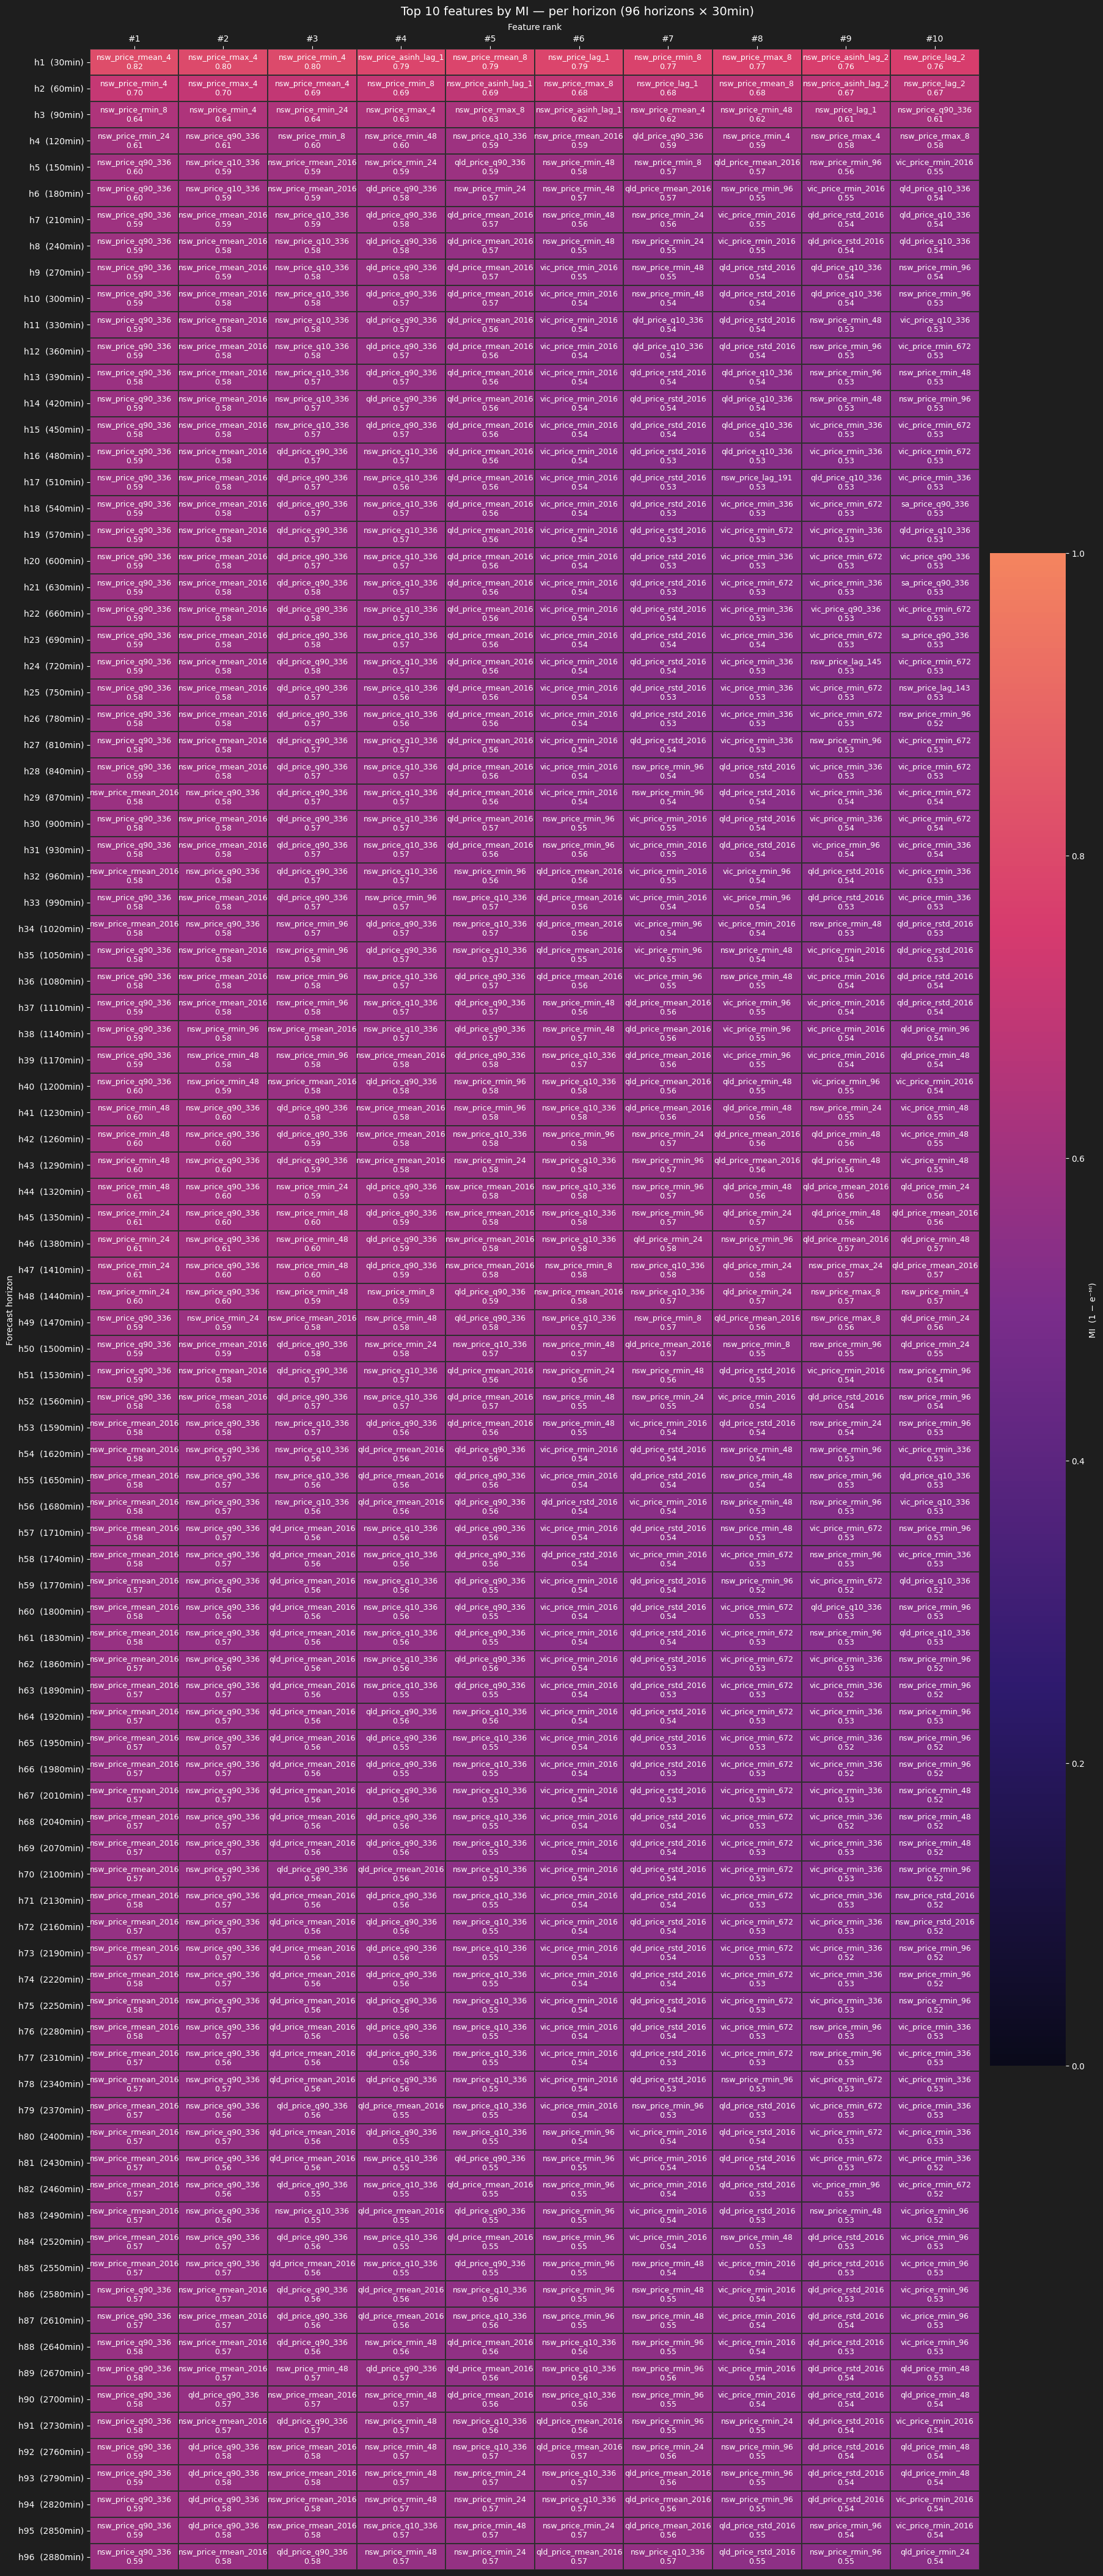

In [7]:
def mi_matrix_per_horizon(mi_df: pd.DataFrame, top_n: int = 20):
    """One heatmap: rows = each horizon, cols = rank 1..top_n,
    cell annotated with feature name + normalised MI value."""
    _cmap = LinearSegmentedColormap.from_list(
        "mi_vibrant", ["#0a0a1a", "#2e1a6e", "#7b2d8b", "#d63a6e", "#f4845f"], N=256
    )

    horizons = list(mi_df.columns)
    n_h = len(horizons)
    mi_norm = 1 - np.exp(-mi_df)  # normalise to [0,1)

    # For each horizon, pick top-N features by normalised MI (descending).
    values = np.zeros((n_h, top_n), dtype=float)
    labels = np.empty((n_h, top_n), dtype=object)
    for i, h in enumerate(horizons):
        s = mi_norm[h].sort_values(ascending=False).head(top_n)
        values[i, :len(s)] = s.values
        labels[i, :len(s)] = [f"{name}\n{val:.2f}" for name, val in s.items()]

    rank_cols = [f"#{r+1}" for r in range(top_n)]
    horizon_labels = [f"h{int(h[1:])}  ({int(h[1:]) * OUTPUT_RESOLUTION}min)" for h in horizons]

    data = pd.DataFrame(values, index=horizon_labels, columns=rank_cols)
    annot = pd.DataFrame(labels, index=horizon_labels, columns=rank_cols)

    cell_w, cell_h = 1.6, 0.42
    fig_w = max(12, top_n * cell_w + 3)
    fig_h = max(8, n_h * cell_h + 2)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        fig.patch.set_facecolor("#1e1e1e")
        ax.set_facecolor("#1e1e1e")

        sns.heatmap(
            data, ax=ax, cmap=_cmap, vmin=0, vmax=1,
            annot=annot.values, fmt="",
            annot_kws={"size": 9, "color": "white"},
            linewidths=0.2, linecolor="#2e2e2e",
            cbar_kws={"label": "MI  (1 − e⁻ᴹᴵ)", "shrink": 0.6, "pad": 0.01},
        )
        ax.xaxis.set_ticks_position("top")
        ax.xaxis.set_label_position("top")
        ax.tick_params(axis="x", labelsize=10, colors="white", rotation=0)
        ax.tick_params(axis="y", labelsize=10, colors="white", rotation=0)
        ax.set_xlabel("Feature rank", color="white", fontsize=10, labelpad=6)
        ax.set_ylabel("Forecast horizon", color="white", fontsize=10)

        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(colors="white")
        cbar.ax.yaxis.label.set_color("white")

        fig.suptitle(
            f"Top {top_n} features by MI — per horizon ({n_h} horizons × {OUTPUT_RESOLUTION}min)",
            color="white", fontsize=14, y=0.995,
        )
        plt.tight_layout()
        plt.show()


mi_matrix_per_horizon(mi_df, top_n=10)
